Load Own Dataset

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
gene_expression = pd.read_csv("/content/drive/MyDrive/Own_Dataset/x_HUGE-FILE-3GB-single_cell_RNA_data.txt", sep='\t')

gene_expression.shape

(25044, 36424)

In [ ]:
gene_expression_t = gene_expression.transpose()
print("\nShape of the data:", gene_expression_t.shape)
print("\nColumn names:", gene_expression_t.columns.tolist()[:10])

columns = gene_expression_t.columns
print(len(columns.unique()))


Shape of the data: (36424, 25044)

Column names: ['RP11-34P13.7', 'RP11-34P13.8', 'FO538757.2', 'AP006222.2', 'RP4-669L17.10', 'RP5-857K21.4', 'RP5-857K21.2', 'RP11-206L10.9', 'FAM87B', 'LINC00115']
25044


In [ ]:
def read_cell_types(file_path):
    cell_types = pd.read_csv(file_path, sep='\t', header=None, skiprows=1, index_col=0)
    cell_types.columns = ['tumourID', 'CellType']
    return cell_types

cell_type_file = "/content/drive/MyDrive/Own_Dataset/13-Patient_singlecell_mRNA.txt"
cell_type = read_cell_types(cell_type_file)

print("\nFirst few rows of cell types data:")
print(cell_type.head())

print("\nShape of the data:", cell_type.shape)
print("\nUnique cell types:", cell_type['CellType'].unique())


First few rows of cell types data:
                   tumourID          CellType
0                                            
AAACCTGAGAGATGAG-1    SC159  Epithelial cells
TGAGGGAGTCATATGC-1    SC159            Others
CTAATGGTCCCAGGTG-1    SC159       Fibroblasts
CTAGAGTTCTGGCGAC-1    SC159  Epithelial cells
CTCGGAGGTGGTGTAG-1    SC159  Epithelial cells

Shape of the data: (21785, 2)

Unique cell types: ['Epithelial cells' 'Others' 'Fibroblasts' 'CD8+ T-cells' 'Macrophages'
 'Monocytes' 'NK cells' 'Endothelial cells' 'HSC' 'DC' 'B-cells'
 'CD4+ T-cells']


In [ ]:
merged_data = pd.merge(cell_type, gene_expression_t, left_index=True, right_index=True, how='inner')
merged_data = merged_data.drop(columns=['tumourID'])

print(merged_data.head())

                            CellType  RP11-34P13.7  RP11-34P13.8  FO538757.2  \
AAACCTGAGAGATGAG-1  Epithelial cells           0.0           0.0    0.320819   
TGAGGGAGTCATATGC-1            Others           0.0           0.0    0.000000   
CTAATGGTCCCAGGTG-1       Fibroblasts           0.0           0.0    0.000000   
CTAGAGTTCTGGCGAC-1  Epithelial cells           0.0           0.0    0.000000   
CTCGGAGGTGGTGTAG-1  Epithelial cells           0.0           0.0    0.000000   

                    AP006222.2  RP4-669L17.10  RP5-857K21.4  RP5-857K21.2  \
AAACCTGAGAGATGAG-1    0.563330            0.0           0.0           0.0   
TGAGGGAGTCATATGC-1    0.000000            0.0           0.0           0.0   
CTAATGGTCCCAGGTG-1    0.000000            0.0           0.0           0.0   
CTAGAGTTCTGGCGAC-1    0.684514            0.0           0.0           0.0   
CTCGGAGGTGGTGTAG-1    0.000000            0.0           0.0           0.0   

                    RP11-206L10.9  FAM87B  ...  AC011043

Data Cleansing

In [ ]:
non_zero_mask = (merged_data.iloc[:, 1:] != 0).any(axis=0)

cleansed_data = pd.concat(
    [merged_data['CellType'], merged_data.iloc[:, 1:].loc[:, non_zero_mask]],
    axis=1
)

cleansed_data = cleansed_data.loc[:, ~cleansed_data.columns.duplicated()]

print(cleansed_data.shape)
print(cleansed_data.head())

(21785, 24788)
                            CellType  RP11-34P13.7  RP11-34P13.8  FO538757.2  \
AAACCTGAGAGATGAG-1  Epithelial cells           0.0           0.0    0.320819   
TGAGGGAGTCATATGC-1            Others           0.0           0.0    0.000000   
CTAATGGTCCCAGGTG-1       Fibroblasts           0.0           0.0    0.000000   
CTAGAGTTCTGGCGAC-1  Epithelial cells           0.0           0.0    0.000000   
CTCGGAGGTGGTGTAG-1  Epithelial cells           0.0           0.0    0.000000   

                    AP006222.2  RP4-669L17.10  RP5-857K21.4  RP5-857K21.2  \
AAACCTGAGAGATGAG-1    0.563330            0.0           0.0           0.0   
TGAGGGAGTCATATGC-1    0.000000            0.0           0.0           0.0   
CTAATGGTCCCAGGTG-1    0.000000            0.0           0.0           0.0   
CTAGAGTTCTGGCGAC-1    0.684514            0.0           0.0           0.0   
CTCGGAGGTGGTGTAG-1    0.000000            0.0           0.0           0.0   

                    RP11-206L10.9  FAM87B

In [ ]:
cleansed_data.to_csv("cleansed_dataset_own.csv", index=True)

In [ ]:
features = cleansed_data.drop(columns=['CellType'])
target = cleansed_data['CellType']
print("\nFeatures shape:", features.shape)
print("Target shape:", target.shape)

print(features.head())
print(target.head())


Features shape: (21785, 24787)
Target shape: (21785,)
                    RP11-34P13.7  RP11-34P13.8  FO538757.2  AP006222.2  \
AAACCTGAGAGATGAG-1           0.0           0.0    0.320819    0.563330   
TGAGGGAGTCATATGC-1           0.0           0.0    0.000000    0.000000   
CTAATGGTCCCAGGTG-1           0.0           0.0    0.000000    0.000000   
CTAGAGTTCTGGCGAC-1           0.0           0.0    0.000000    0.684514   
CTCGGAGGTGGTGTAG-1           0.0           0.0    0.000000    0.000000   

                    RP4-669L17.10  RP5-857K21.4  RP5-857K21.2  RP11-206L10.9  \
AAACCTGAGAGATGAG-1            0.0           0.0           0.0            0.0   
TGAGGGAGTCATATGC-1            0.0           0.0           0.0            0.0   
CTAATGGTCCCAGGTG-1            0.0           0.0           0.0            0.0   
CTAGAGTTCTGGCGAC-1            0.0           0.0           0.0            0.0   
CTCGGAGGTGGTGTAG-1            0.0           0.0           0.0            0.0   

                   

Data Analysis

In [4]:
cleansed_data = pd.read_csv("/content/drive/MyDrive/Processed/cleansed_dataset_own.csv", index_col=0)

cleansed_data.shape

(21785, 24788)

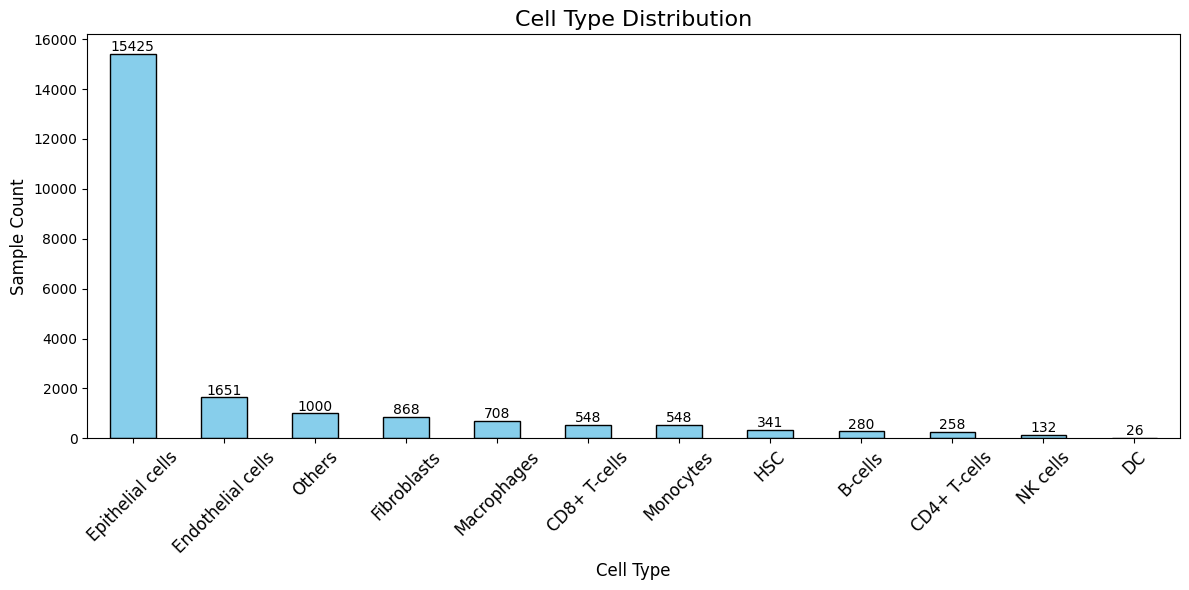

In [ ]:
cell_type_counts = cleansed_data['CellType'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
ax = cell_type_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Cell Type Distribution', fontsize=16)
plt.xlabel('Cell Type', fontsize=12)
plt.ylabel('Sample Count', fontsize=12)
for i, count in enumerate(cell_type_counts):
    ax.text(i, count + 100, str(count), ha='center', fontsize=10)
plt.xticks(rotation=45, fontsize=12, ha='center')
plt.tight_layout()
plt.show()


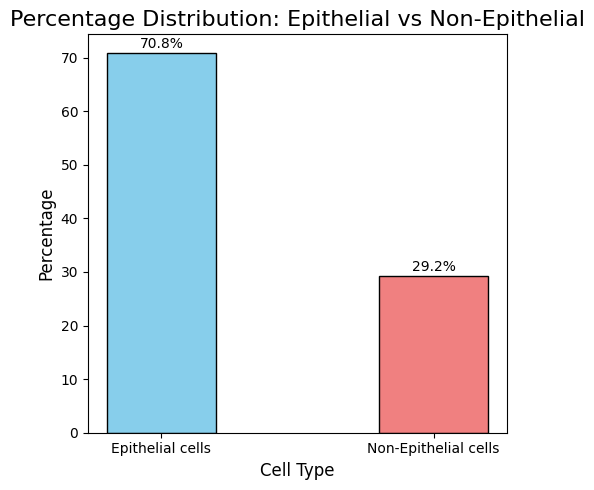

In [ ]:
epithelial_count = cleansed_data['CellType'].str.contains('Epithelial cells').sum()
non_epithelial_count = len(cleansed_data) - epithelial_count

total_count = epithelial_count + non_epithelial_count
epithelial_percentage = (epithelial_count / total_count) * 100
non_epithelial_percentage = (non_epithelial_count / total_count) * 100

categories = ['Epithelial cells', 'Non-Epithelial cells']
percentages = [epithelial_percentage, non_epithelial_percentage]

plt.figure(figsize=(5, 5))
plt.bar(categories, percentages, width=0.4, color=['skyblue', 'lightcoral'], edgecolor='black')

for i, pct in enumerate(percentages):
    plt.text(i, pct + 1, f'{pct:.1f}%', ha='center', fontsize=10)

plt.title('Percentage Distribution: Epithelial vs Non-Epithelial', fontsize=16)
plt.xlabel('Cell Type', fontsize=12)
plt.ylabel('Percentage', fontsize=12)
plt.xticks(fontsize=10)
plt.tight_layout()

plt.show()

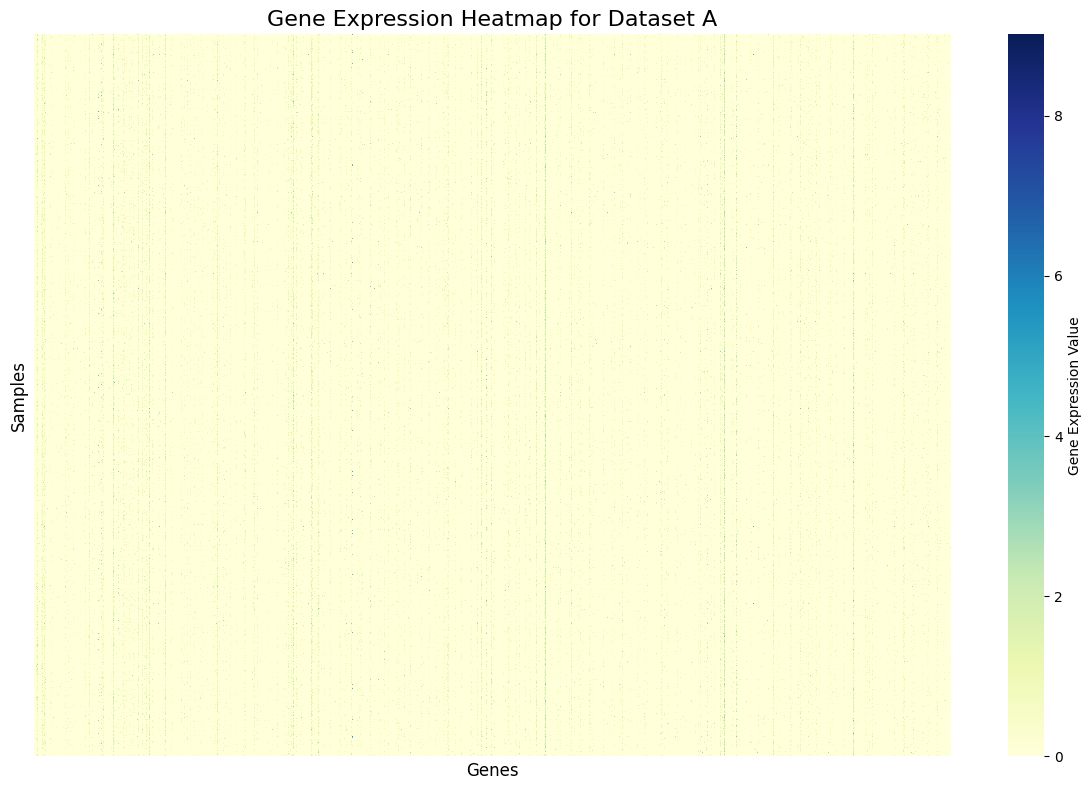

In [5]:
heatmap_data = cleansed_data.iloc[:, 1:]
heatmap_data = heatmap_data.sample(n=5000, axis=0)
heatmap_data = heatmap_data.iloc[:, :5000]

plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    xticklabels=False,
    yticklabels=False,
    cbar_kws={'label': 'Gene Expression Value'}
)

plt.title('Gene Expression Heatmap for Dataset A', fontsize=16)
plt.xlabel('Genes', fontsize=12)
plt.ylabel('Samples', fontsize=12)

plt.tight_layout()
plt.show()

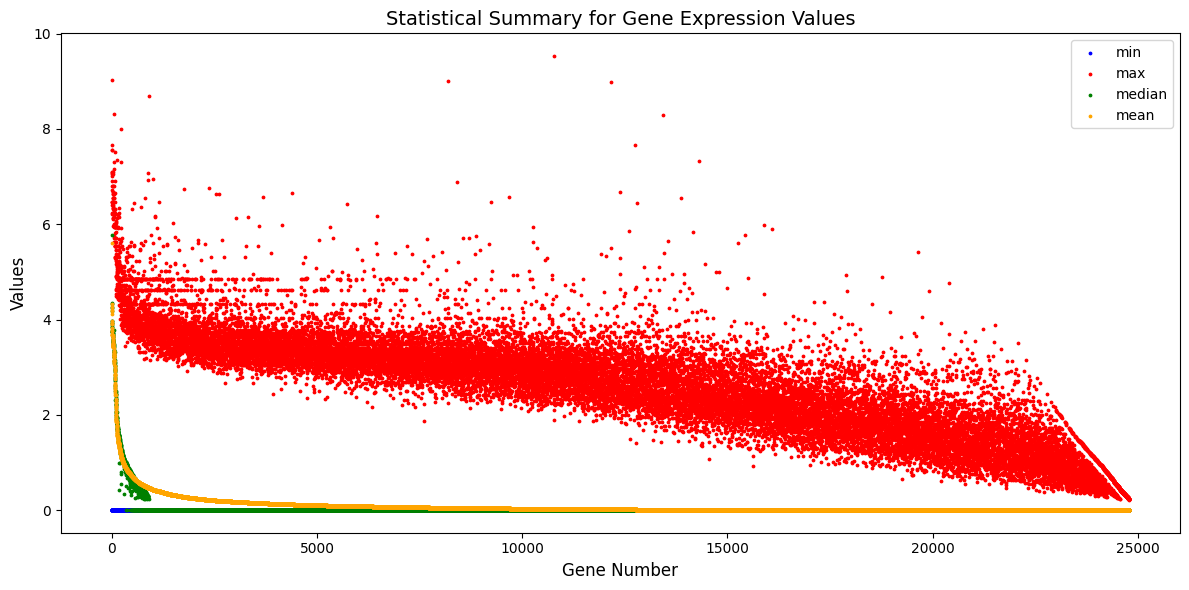

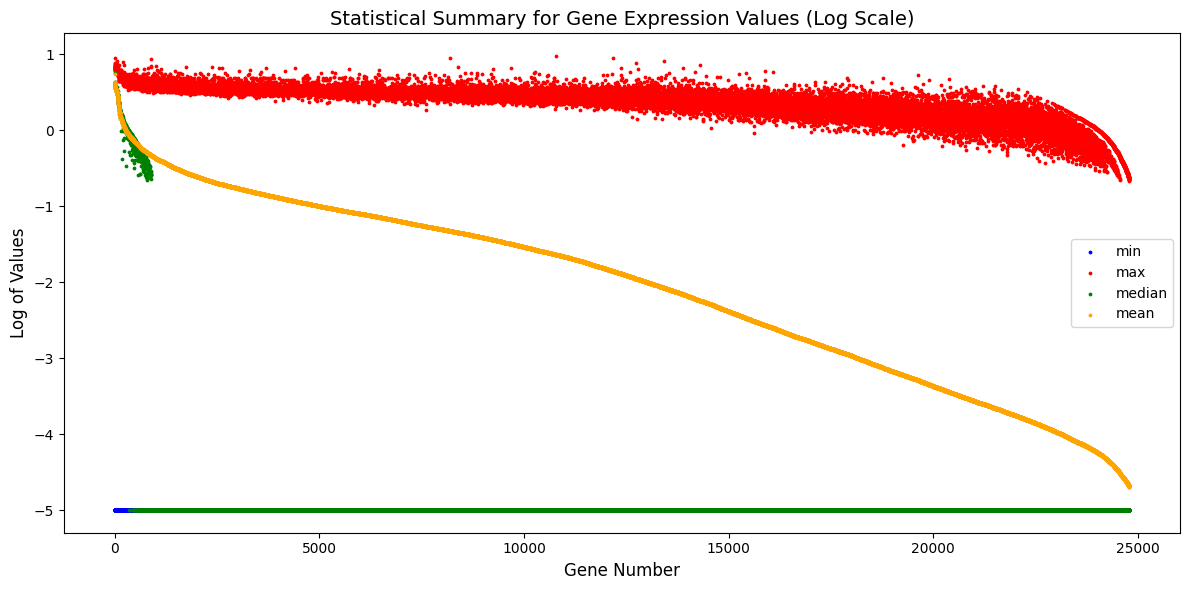

In [ ]:
gene_data = cleansed_data.iloc[:, 1:]

gene_min = gene_data.min(axis=0)
gene_max = gene_data.max(axis=0)
gene_median = gene_data.median(axis=0)
gene_mean = gene_data.mean(axis=0)

gene_stats = pd.DataFrame({
    'min': gene_min,
    'max': gene_max,
    'median': gene_median,
    'mean': gene_mean
})

gene_stats = gene_stats.sort_values(by='mean', ascending=False)

plt.figure(figsize=(12, 6))
plt.scatter(range(len(gene_stats)), gene_stats['min'], label='min', s=3, color='blue')
plt.scatter(range(len(gene_stats)), gene_stats['max'], label='max', s=3, color='red')
plt.scatter(range(len(gene_stats)), gene_stats['median'], label='median', s=3, color='green')
plt.scatter(range(len(gene_stats)), gene_stats['mean'], label='mean', s=3, color='orange')
plt.title('Statistical Summary for Gene Expression Values', fontsize=14)
plt.xlabel('Gene Number', fontsize=12)
plt.ylabel('Values', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.scatter(range(len(gene_stats)), np.log10(gene_stats['min'] + 1e-5), label='min', s=3, color='blue')
plt.scatter(range(len(gene_stats)), np.log10(gene_stats['max'] + 1e-5), label='max', s=3, color='red')
plt.scatter(range(len(gene_stats)), np.log10(gene_stats['median'] + 1e-5), label='median', s=3, color='green')
plt.scatter(range(len(gene_stats)), np.log10(gene_stats['mean'] + 1e-5), label='mean', s=3, color='orange')
plt.title('Statistical Summary for Gene Expression Values (Log Scale)', fontsize=14)
plt.xlabel('Gene Number', fontsize=12)
plt.ylabel('Log of Values', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()